In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv('J:\\pdr\\Balanced_Gait_Dataset.csv')

# Group by 'Gender' and 'Status' and get the size of each group
grouped_counts = df.groupby(['Gender', 'Status']).size().reset_index(name='Count')

# Find the minimum count among the groups
min_count = grouped_counts['Count'].min()

# Create a new balanced dataframe
balanced_df = pd.DataFrame()

# Subsample each group to the minimum count and append to the new dataframe
for gender in df['Gender'].unique():
    for status in df['Status'].unique():
        # Filter for the specific group
        group_df = df[(df['Gender'] == gender) & (df['Status'] == status)]
        # Sample the minimum count from the group
        sampled_df = group_df.sample(n=min_count, random_state=42)
        # Append to the balanced dataframe
        balanced_df = pd.concat([balanced_df, sampled_df])

# Shuffle the balanced dataframe
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the balanced dataset to a new CSV file with a valid filename
balanced_df.to_csv('J:\\pdr\\balanced_gender_status_dataset.csv', index=False)

# Verify the balance in the new dataframe and print the counts
print("Counts after balancing:")
print("Gender distribution:")
print(balanced_df['Gender'].value_counts())
print("\nStatus distribution:")
print(balanced_df['Status'].value_counts())

Counts after balancing:
Gender distribution:
male      60356
female    60356
Name: Gender, dtype: int64

Status distribution:
1    60356
0    60356
Name: Status, dtype: int64


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Load dataset
df = pd.read_csv("J:\\pdr\\balanced_gender_status_dataset.csv")

# Select features and target
features = ['Gender', 'L Accel X (g)', 'L Accel Y (g)', 'L Accel Z (g)', 
            'R Accel X (g)', 'R Accel Y (g)', 'R Accel Z (g)']
target = 'Status'

# Encode categorical gender feature
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])  # male=1, female=0

# Prepare data
X = df[features]
y = df[target]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split: 80% train, 5% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.0588, random_state=42, stratify=y_temp)
# 0.0588 ≈ 5% of total dataset

# Define models
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'NaiveBayes': GaussianNB(),
    'KNN': KNeighborsClassifier()
}

# Train, evaluate, and report
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    test_preds = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_preds)
    report = classification_report(y_test, test_preds)
    
    print(f"=== {name} ===")
    print(f"Train Accuracy:      {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy:       {test_acc:.4f}")
    print("\nClassification Report (Test):")
    print(report)
    print("=" * 40)


=== RandomForest ===
Train Accuracy:      1.0000
Validation Accuracy: 0.8848
Test Accuracy:       0.8815

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      9054
           1       0.89      0.87      0.88      9053

    accuracy                           0.88     18107
   macro avg       0.88      0.88      0.88     18107
weighted avg       0.88      0.88      0.88     18107

=== LogisticRegression ===
Train Accuracy:      0.5677
Validation Accuracy: 0.5693
Test Accuracy:       0.5704

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.58      0.54      0.56      9054
           1       0.57      0.60      0.58      9053

    accuracy                           0.57     18107
   macro avg       0.57      0.57      0.57     18107
weighted avg       0.57      0.57      0.57     18107

=== NaiveBayes ===
Train Accuracy:      0.5638
Validation Accuracy: 

In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, xgb_model.predict(X_train))
val_acc = accuracy_score(y_val, xgb_model.predict(X_val))
test_preds = xgb_model.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)

print("=== XGBoost ===")
print(f"Train Accuracy:      {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, test_preds))


C:\Users\rahee\anaconda3\envs\GPU\lib\site-packages\xgboost\core.py:158: UserWarning: [09:24:20] WARNING: D:\bld\xgboost-split_1724807710452\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


=== XGBoost ===
Train Accuracy:      0.8491
Validation Accuracy: 0.8266
Test Accuracy:       0.8249

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      9054
           1       0.83      0.81      0.82      9053

    accuracy                           0.82     18107
   macro avg       0.83      0.82      0.82     18107
weighted avg       0.83      0.82      0.82     18107



In [14]:
import joblib

# If you previously used: models = {'KNN': KNeighborsClassifier(), ...}
# Then use this:
knn_bundle = {
    'model': models['KNN'],   # ✅ Access KNN from the models dictionary
    'scaler': scaler          # ✅ Scaler used for standardization
}

# Save the bundled object to a file
joblib.dump(knn_bundle, 'J:\\pdr\\knn_model_with_scaler.pkl')


['J:\\pdr\\knn_model_with_scaler.pkl']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score, roc_auc_score,
    roc_curve, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# === Load dataset ===
df = pd.read_csv("J:\\pdr\\balanced_gender_status_dataset.csv")

# === Feature and target selection ===
features = ['Gender', 'L Accel X (g)', 'L Accel Y (g)', 'L Accel Z (g)',
            'R Accel X (g)', 'R Accel Y (g)', 'R Accel Z (g)']
target = 'Status'

# === Encode categorical variables ===
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])  # Male=1, Female=0
label_encoder = LabelEncoder()
df[target] = label_encoder.fit_transform(df[target])       # Encode target

# === Prepare features and labels ===
X = df[features]
y = df[target]

# === Scale features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === Split dataset ===
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.0588, stratify=y_temp, random_state=42)
# 0.0588 ≈ 5% of total data for validation

# === Define models ===
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'NaiveBayes': GaussianNB(),
    'KNN': KNeighborsClassifier()
}

# === Store results ===
metrics = {
    'Model': [],
    'Train Accuracy': [],
    'Validation Accuracy': [],
    'Test Accuracy': [],
    'ROC AUC': []
}

# === Plot ROC Curves ===
plt.figure(figsize=(10, 7))
colors = ['blue', 'green', 'red', 'purple']

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # Accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # ROC AUC (for binary only)
    if len(np.unique(y)) == 2:
        y_test_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_test_proba)
        auc = roc_auc_score(y_test, y_test_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})', color=colors[idx])
    else:
        auc = np.nan

    # Save metrics
    metrics['Model'].append(name)
    metrics['Train Accuracy'].append(train_acc)
    metrics['Validation Accuracy'].append(val_acc)
    metrics['Test Accuracy'].append(test_acc)
    metrics['ROC AUC'].append(auc)

    # === Print classification report and confusion matrix ===
    print(f"\n=== {name} ===")
    print(f"Train Accuracy:      {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy:       {test_acc:.4f}\n")
    
    # Convert label classes to string for compatibility
    target_names = [str(cls) for cls in label_encoder.classes_]
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=target_names))
    
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)
    print("=" * 50)

# === Final ROC Curve plot ===
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Accuracy Comparison Bar Plot ===
metrics_df = pd.DataFrame(metrics)
metrics_df.set_index("Model")[["Train Accuracy", "Validation Accuracy", "Test Accuracy"]].plot(
    kind='bar', figsize=(10, 6), colormap='Set2'
)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)


=== RandomForest ===
Train Accuracy:      1.0000
Validation Accuracy: 0.8848
Test Accuracy:       0.8815

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      9054
           1       0.89      0.87      0.88      9053

    accuracy                           0.88     18107
   macro avg       0.88      0.88      0.88     18107
weighted avg       0.88      0.88      0.88     18107

Confusion Matrix:
[[8052 1002]
 [1143 7910]]

=== LogisticRegression ===
Train Accuracy:      0.5677
Validation Accuracy: 0.5693
Test Accuracy:       0.5704

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.54      0.56      9054
           1       0.57      0.60      0.58      9053

    accuracy                           0.57     18107
   macro avg       0.57      0.57      0.57     18107
weighted avg       0.57      0.57      0.57     18107

Confusion Matrix:
[[4886 4168]
 [36

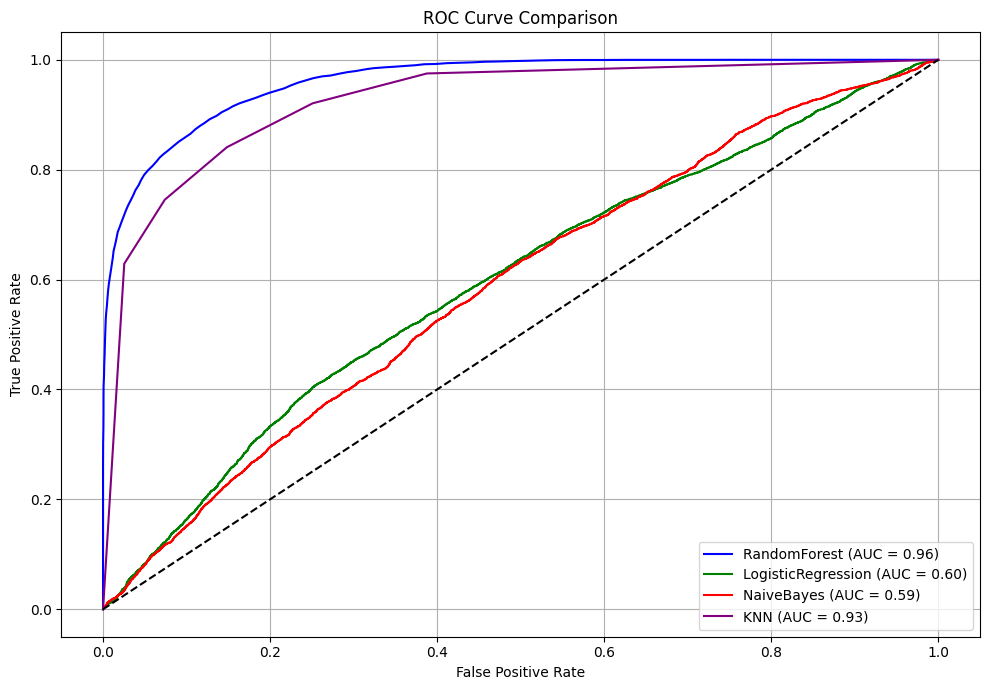

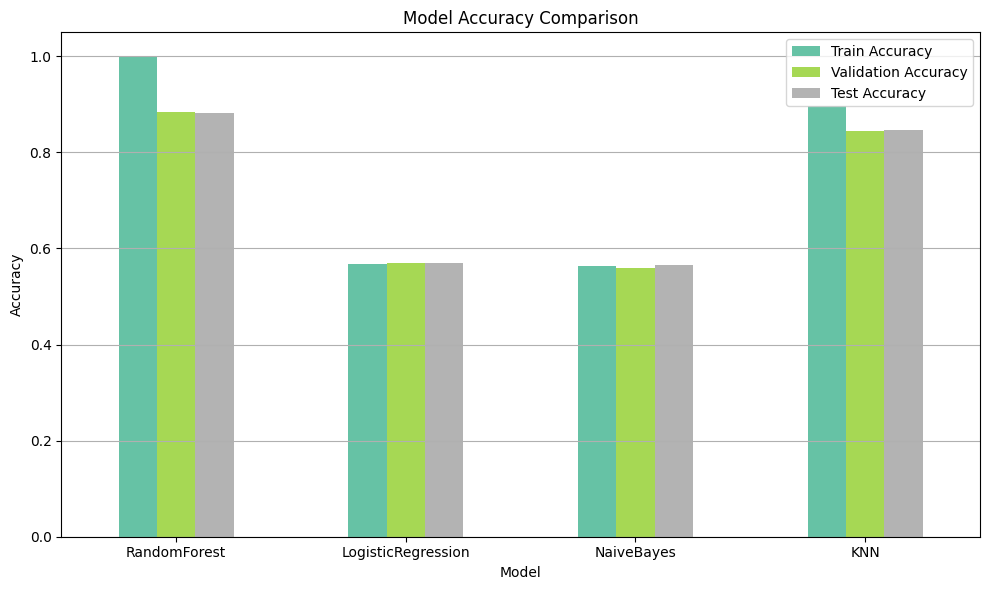

In [ ]:
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

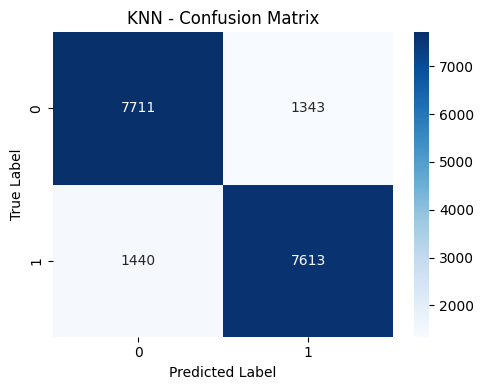

In [8]:
# Confusion matrix as heatmap
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f"{name} - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


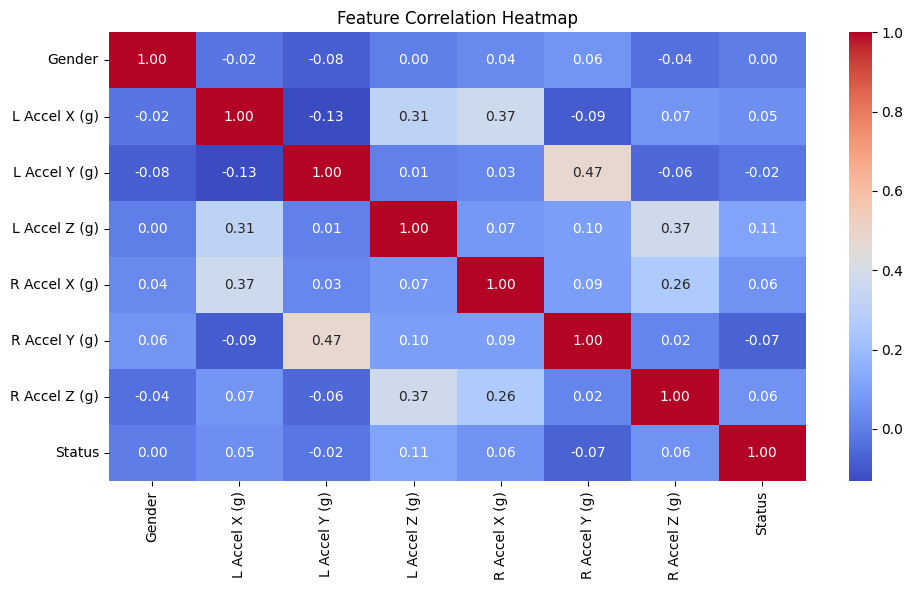

In [10]:
# --- Correlation Heatmap ---
plt.figure(figsize=(10, 6))
sns.heatmap(df[features + [target]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


Confusion Matrix:
[[7711 1343]
 [1440 7613]]


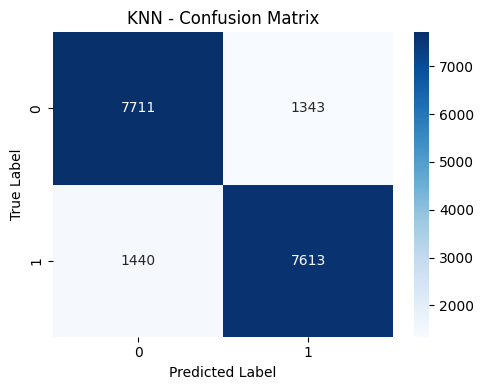

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

# Heatmap for Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f"{name} - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [ ]:
for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # Accuracy and ROC logic...

    print(f"\n=== {name} ===")
    print(f"Train Accuracy:      {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy:       {test_acc:.4f}\n")

    # Classification Report
    target_names = [str(cls) for cls in label_encoder.classes_]
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=target_names))

    # === Confusion Matrix (Print + Plot) ===
    cm = confusion_matrix(y_test, y_test_pred)
    print("Confusion Matrix:")
    print(cm)

    # Heatmap
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


=== RandomForest ===
Train Accuracy:      0.8960
Validation Accuracy: 0.8442
Test Accuracy:       0.8463

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      9054
           1       0.89      0.87      0.88      9053

    accuracy                           0.88     18107
   macro avg       0.88      0.88      0.88     18107
weighted avg       0.88      0.88      0.88     18107

Confusion Matrix:
[[8052 1002]
 [1143 7910]]


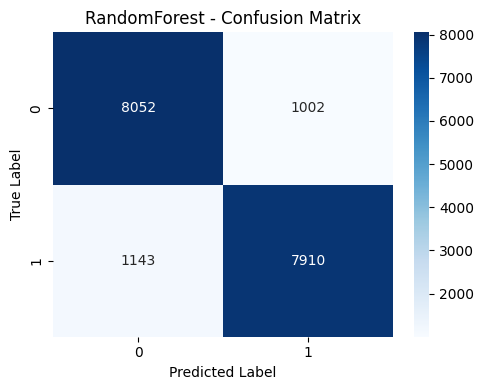


=== LogisticRegression ===
Train Accuracy:      0.8960
Validation Accuracy: 0.8442
Test Accuracy:       0.8463

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.54      0.56      9054
           1       0.57      0.60      0.58      9053

    accuracy                           0.57     18107
   macro avg       0.57      0.57      0.57     18107
weighted avg       0.57      0.57      0.57     18107

Confusion Matrix:
[[4886 4168]
 [3611 5442]]


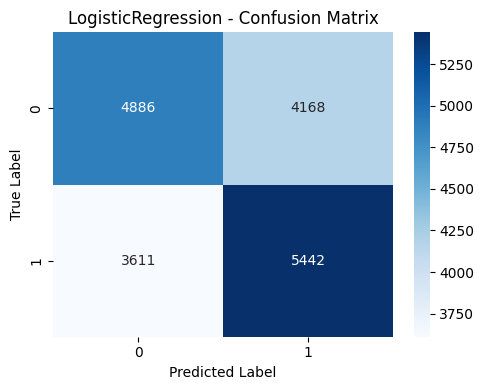


=== NaiveBayes ===
Train Accuracy:      0.8960
Validation Accuracy: 0.8442
Test Accuracy:       0.8463

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.52      0.55      9054
           1       0.56      0.61      0.59      9053

    accuracy                           0.57     18107
   macro avg       0.57      0.57      0.57     18107
weighted avg       0.57      0.57      0.57     18107

Confusion Matrix:
[[4705 4349]
 [3507 5546]]


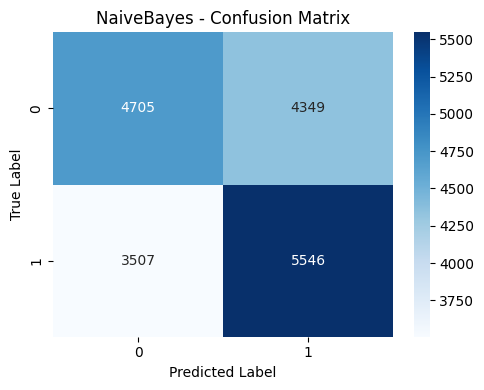


=== KNN ===
Train Accuracy:      0.8960
Validation Accuracy: 0.8442
Test Accuracy:       0.8463

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      9054
           1       0.85      0.84      0.85      9053

    accuracy                           0.85     18107
   macro avg       0.85      0.85      0.85     18107
weighted avg       0.85      0.85      0.85     18107

Confusion Matrix:
[[7711 1343]
 [1440 7613]]


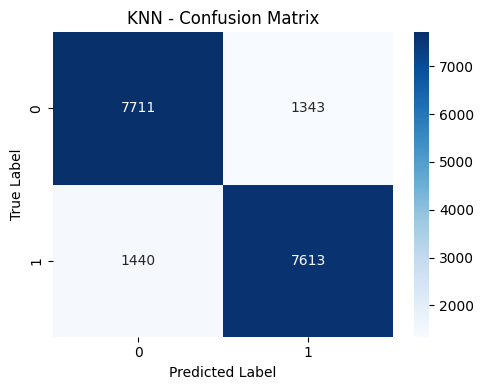